In [1]:
# ============================================================
# 单元格1：初始化环境 + 三分类函数定义（完整版）
# 版本：v1.1_三分类_完整可直接替换
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# 检查依赖
print("🔍 检查依赖包...")
try:
    import librosa
    import numpy as np
    import tensorflow as tf
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.utils.class_weight import compute_class_weight
    import matplotlib.pyplot as plt
    import joblib
    import os
    from collections import Counter, defaultdict
    from datetime import datetime
    import json
    print("✅ 所有依赖包已正确导入")
except ImportError as e:
    print(f"❌ 缺少依赖包: {e}")
    print("请运行: pip install librosa numpy tensorflow scikit-learn matplotlib joblib")

# ---------------------------------------------------------
# 1. 读取标签函数（保持不变）
# ---------------------------------------------------------
def read_numeric_labels_v1(label_file_path):
    """读取Audacity导出的标签文件，只读取1和2，自动转为0和1"""
    annotations = []
    label_stats = {'1': 0, '2': 0, 'other': 0}
    
    try:
        with open(label_file_path, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(f, 1):
                line = line.strip()
                if not line:
                    continue
                    
                parts = line.split('\t')
                if len(parts) < 3:
                    continue
                
                try:
                    start_time = float(parts[0])
                    end_time = float(parts[1])
                    label_str = parts[2].strip()
                    
                    if label_str == '1':
                        annotations.append((start_time, end_time, 0))
                        label_stats['1'] += 1
                    elif label_str == '2':
                        annotations.append((start_time, end_time, 1))
                        label_stats['2'] += 1
                    else:
                        label_stats['other'] += 1
                        
                except ValueError:
                    continue
                    
    except FileNotFoundError:
        print(f"❌ 找不到文件: {label_file_path}")
        return [], label_stats
    
    return annotations, label_stats

# ---------------------------------------------------------
# 2. 特征提取函数（保持不变）
# ---------------------------------------------------------
def extract_enhanced_features_v1(audio_segment, sr):
    """提取音频特征，返回特征数组"""
    features = []
    
    # 1. 时域特征
    rms = librosa.feature.rms(y=audio_segment)[0]
    features.extend([np.mean(rms), np.std(rms), np.max(rms)])
    
    # 2. 过零率
    zcr = librosa.feature.zero_crossing_rate(audio_segment)[0]
    features.extend([np.mean(zcr), np.std(zcr)])
    
    # 3. 频谱质心
    spectral_centroid = librosa.feature.spectral_centroid(y=audio_segment, sr=sr)[0]
    features.extend([np.mean(spectral_centroid), np.std(spectral_centroid)])
    
    # 4. 频谱带宽
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio_segment, sr=sr)[0]
    features.extend([np.mean(spectral_bandwidth), np.std(spectral_bandwidth)])
    
    # 5. MFCC特征（13个系数）
    mfcc = librosa.feature.mfcc(y=audio_segment, sr=sr, n_mfcc=13)
    for i in range(13):
        features.append(np.mean(mfcc[i]))
    
    # 6. 频谱衰减点
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio_segment, sr=sr)[0]
    features.append(np.mean(spectral_rolloff))
    
    return np.array(features)

# ---------------------------------------------------------
# 3. 三分类数据处理函数（核心修改：自动标记背景为2）
# ---------------------------------------------------------
def process_multiple_v2(audio_label_pairs, segment_length=2.0, overlap=0.5, config_name="default"):
    """
    处理多个音频-标签对，提取特征和标签（三分类版）
    版本：v2.1_三分类
    
    标签规则：
    - 与标记区域（0或1）重叠>50% → 使用该标记标签
    - 与任何标记区域重叠<50% → 标记为背景（2）
    """
    all_features = []
    all_labels = []
    
    print(f"⚙️  处理配置 [{config_name}]: 窗口={segment_length}s, 重叠={overlap}")
    print(f"   🏷️  标签规则: 0=正常吸气, 1=严重吸气, 2=背景/呼气")
    
    for audio_path, label_path in audio_label_pairs:
        if not os.path.exists(audio_path) or not os.path.exists(label_path):
            print(f"⚠️  跳过: 文件不存在 {audio_path} 或 {label_path}")
            continue
            
        # 1. 读取音频
        try:
            y_audio, sr = librosa.load(audio_path, sr=None)
        except:
            # 2. 失败则尝试pydub转换（m4a等）
            from pydub import AudioSegment
            import io
            ext = os.path.splitext(audio_path)[1].lower()
            format_map = {'.m4a': 'mp4', '.aac': 'aac', '.ogg': 'ogg'}
            audio = AudioSegment.from_file(audio_path, format=format_map.get(ext, ext[1:]))
            buf = io.BytesIO()
            audio.export(buf, format="wav")
            buf.seek(0)
            y_audio, sr = librosa.load(buf, sr=None)
        
        # 2. 读取标签（只包含0和1）
        annotations, stats = read_numeric_labels_v1(label_path)
        
        # 3. 切分音频并提取特征
        samples_per_segment = int(segment_length * sr)
        step_samples = int(samples_per_segment * (1 - overlap))
        
        bg_count = 0  # 背景计数
        snore_count = 0  # 鼾声计数
        
        for start in range(0, len(y_audio) - samples_per_segment, step_samples):
            end = start + samples_per_segment
            segment = y_audio[start:end]
            segment_start_time = start / sr
            segment_end_time = end / sr
            
            # 提取特征
            features = extract_enhanced_features_v1(segment, sr)
            
            # 确定标签（基于时间重叠）
            max_overlap_duration = 0
            segment_label = 2  # 默认背景
            
            for ann_start, ann_end, ann_label in annotations:
                # 计算时间重叠
                overlap_start = max(segment_start_time, ann_start)
                overlap_end = min(segment_end_time, ann_end)
                overlap_duration = max(0, overlap_end - overlap_start)
                
                # 如果与标记区域重叠超过50%，使用该标签
                if overlap_duration > (segment_length * 0.5):
                    segment_label = ann_label
                    max_overlap_duration = overlap_duration
                    break  # 优先匹配第一个符合条件的标记
            
            if segment_label == 2:
                bg_count += 1
            else:
                snore_count += 1
            
            all_features.append(features)
            all_labels.append(segment_label)
        
        print(f"   📄 {os.path.basename(audio_path)}: 吸气鼾声={snore_count}个, 背景/呼气={bg_count}个")
    
    if len(all_features) == 0:
        print("❌ 未生成任何样本")
        return None, None
    
    X = np.array(all_features)
    y = np.array(all_labels)
    
    # 统计三类分布
    count_0 = np.sum(y == 0)
    count_1 = np.sum(y == 1)
    count_2 = np.sum(y == 2)
    
    print(f"✅ 配置 [{config_name}] 完成: 生成 {len(X)} 个样本")
    print(f"   类别分布: 正常={count_0}, 严重={count_1}, 背景={count_2}")
    
    return X, y

# ---------------------------------------------------------
# 4. 分层合并函数（新增：按skills要求的分层合并）
# ---------------------------------------------------------
def merge_events_hierarchical_v1(segments, max_gap=0.5, short_gap=0.3):
    """
    分层合并策略（三分类版）
    
    步骤：
    1. 按类型分别合并相邻片段（0+0, 1+1, 2+2）
    2. 识别"短间隙"（类型2且持续时间 < short_gap）
    3. 对于被短间隙分隔的同类吸气事件（0-0或1-1），跨间隙合并
    
    参数：
    - max_gap: 同类事件合并的最大间隔（秒）
    - short_gap: 被视为"短间隙"的阈值（秒），建议0.3s
    """
    if not segments:
        return []
    
    # 步骤1：按类型分组并初步合并（同类相邻合并）
    def merge_same_type(segs, gap_threshold):
        """合并同类型且时间相邻的片段"""
        if not segs:
            return []
        
        segs_sorted = sorted(segs, key=lambda x: x['start'])
        merged = []
        current = segs_sorted[0].copy()
        
        for next_seg in segs_sorted[1:]:
            # 检查是否同类型且间隔小
            if (next_seg['type'] == current['type'] and 
                next_seg['start'] - current['end'] <= gap_threshold):
                # 合并
                current['end'] = next_seg['end']
                current['duration'] = current['end'] - current['start']
                # 保留最高置信度
                current['confidence'] = max(current['confidence'], next_seg['confidence'])
                # 累积片段计数
                current['segment_count'] = current.get('segment_count', 1) + 1
            else:
                merged.append(current)
                current = next_seg.copy()
        
        merged.append(current)
        return merged
    
    # 按类型分组
    segs_0 = [s for s in segments if s['type'] == 0]  # 正常
    segs_1 = [s for s in segments if s['type'] == 1]  # 严重
    segs_2 = [s for s in segments if s['type'] == 2]  # 背景/呼气
    
    # 初步合并各类
    merged_0 = merge_same_type(segs_0, max_gap)
    merged_1 = merge_same_type(segs_1, max_gap)
    merged_2 = merge_same_type(segs_2, max_gap)  # 呼气合并
    
    print(f"   [合并步骤1] 初步合并: 正常={len(merged_0)}个, 严重={len(merged_1)}个, 呼气/间隙={len(merged_2)}个")
    
    # 步骤2&3：处理短间隙，跨间隙合并同类事件
    def merge_across_gaps(main_events, gap_events, gap_time_threshold):
        """
        如果被短的gap_event分隔，则合并同类main_events
        例如: [正常事件A] - [短间隙] - [正常事件B] → 合并为单个正常事件
        """
        if not gap_events or len(main_events) < 2:
            return main_events
        
        # 按时间排序所有事件
        all_events = sorted(main_events + gap_events, key=lambda x: x['start'])
        result = []
        i = 0
        
        while i < len(all_events):
            current = all_events[i]
            
            # 如果是吸气事件，检查下一个是否是短间隙，再下一个是否是同类
            if current.get('type') in [0, 1] and i + 2 < len(all_events):
                next_event = all_events[i + 1]
                after_next = all_events[i + 2]
                
                # 检查中间是否是短的间隙（类型2且持续时间短）
                if (next_event.get('type') == 2 and 
                    next_event.get('duration', 0) < gap_time_threshold and
                    after_next.get('type') == current['type']):
                    
                    # 跨间隙合并：current + gap + after_next
                    merged_event = {
                        'start': current['start'],
                        'end': after_next['end'],
                        'type': current['type'],
                        'duration': after_next['end'] - current['start'],
                        'confidence': max(current['confidence'], after_next['confidence']),
                        'segment_count': (current.get('segment_count', 1) + 
                                        next_event.get('segment_count', 1) + 
                                        after_next.get('segment_count', 1)),
                        'has_gap': True,  # 标记包含间隙
                        'gap_duration': next_event['duration']
                    }
                    result.append(merged_event)
                    i += 3  # 跳过已处理的3个事件
                    continue
            
            # 不合并，直接添加
            if current.get('type') in [0, 1]:
                result.append(current)
            i += 1
        
        return result
    
    # 对正常和严重分别进行跨间隙合并
    final_0 = merge_across_gaps(merged_0, merged_2, short_gap)
    final_1 = merge_across_gaps(merged_1, merged_2, short_gap)
    
    print(f"   [合并步骤2] 跨短间隙合并后: 正常={len(final_0)}个, 严重={len(final_1)}个")
    
    # 合并所有事件（0,1,2），按时间排序，用于后续分析
    all_merged = sorted(final_0 + final_1 + merged_2, key=lambda x: x['start'])
    
    return all_merged

# ---------------------------------------------------------
# 5. 用户视角输出函数（三分类适配版）
# ---------------------------------------------------------
def user_perspective_output_v1(events, total_duration):
    """
    生成用户视角的输出（只显示0和1类事件，2类作为间隙不显示）
    """
    print("\n" + "="*80)
    print("👤 用户视角报告（吸气鼾声检测）")
    print("="*80)
    
    # 过滤掉背景类（2），只显示吸气鼾声
    snore_events = [e for e in events if e['type'] in [0, 1]]
    
    if not snore_events:
        print("📊 未检测到鼾声事件")
        return
    
    type_names = {0: "正常吸气", 1: "严重吸气"}
    
    # 统计信息
    type_counts = defaultdict(int)
    total_snore_time = 0
    
    print(f"{'开始时间':<12} {'结束时间':<12} {'持续时间':<10} {'类型':<12} {'置信度':<8} {'片段数':<8}")
    print("-"*70)
    
    for i, event in enumerate(snore_events, 1):
        duration = event['duration']
        
        # 格式化时间输出
        start_str = f"{event['start']:.1f}s"
        end_str = f"{event['end']:.1f}s"
        duration_str = f"{duration:.1f}s"
        type_str = type_names[event['type']]
        conf_str = f"{event['confidence']:.2f}"
        seg_str = str(event.get('segment_count', 1))
        
        # 如果有跨间隙标记，显示提示
        gap_info = ""
        if event.get('has_gap'):
            gap_info = f"(含{event['gap_duration']:.1f}s间隙)"
        
        print(f"{start_str:<12} {end_str:<12} {duration_str:<10} {type_str:<12} {conf_str:<8} {seg_str:<8} {gap_info}")
        
        # 统计
        type_counts[event['type']] += 1
        total_snore_time += duration
    
    # 汇总统计
    print("\n" + "="*80)
    print("📈 汇总统计")
    print("-"*80)
    
    print(f"🔹 音频总时长: {total_duration:.1f}秒")
    print(f"🔹 检测到吸气鼾声事件: {len(snore_events)}个")
    
    for type_id, type_name in type_names.items():
        count = type_counts[type_id]
        if count > 0:
            print(f"  - {type_name}: {count}个")
    
    print(f"🔹 吸气鼾声总持续时间: {total_snore_time:.1f}秒")
    print(f"🔹 吸气鼾声时间占比: {(total_snore_time/total_duration)*100:.1f}%")
    
    # 计算呼气/间隙时间（用于参考）
    bg_events = [e for e in events if e['type'] == 2]
    if bg_events:
        total_bg_time = sum(e['duration'] for e in bg_events)
        print(f"🔹 呼气/间隙总时间: {total_bg_time:.1f}秒 ({(total_bg_time/total_duration)*100:.1f}%)")

    # 医疗风险评估
    print("\n" + "="*80)
    print("⚠️  医疗风险评估")
    print("-"*80)
    
    if type_counts[1] > 0:
        severe_duration = sum([e['duration'] for e in snore_events if e['type'] == 1])
        severe_ratio = (severe_duration / total_duration) * 100
        
        print(f"🔴 检测到严重吸气鼾声: {type_counts[1]}个事件")
        print(f"🔴 严重吸气鼾声总时间: {severe_duration:.1f}秒")
        print(f"🔴 严重吸气鼾声时间占比: {severe_ratio:.1f}%")
        
        # 风险评估
        if severe_ratio > 10:
            print(f"🚨 高风险: 严重鼾声占比超过10%，建议就医检查")
        elif severe_ratio > 5:
            print(f"⚠️  中风险: 严重鼾声占比5-10%，建议监测")
        else:
            print(f"✅ 低风险: 严重鼾声占比低于5%")
    else:
        print("✅ 未检测到严重吸气鼾声")
    
    # 保存到文件
    output_data = {
        'analysis_time': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'total_duration': total_duration,
        'total_events': len(snore_events),
        'events': snore_events,
        'summary': {
            'normal_count': type_counts[0],
            'severe_count': type_counts[1],
            'total_snore_time': total_snore_time,
            'snore_ratio': (total_snore_time/total_duration)*100
        }
    }
    
    with open('user_report_v1.json', 'w', encoding='utf-8') as f:
        json.dump(output_data, f, ensure_ascii=False, indent=2)
    
    print(f"\n✅ 用户报告已保存到: user_report_v1.json")

# ---------------------------------------------------------
# 6. 保存数据到文件（保持不变）
# ---------------------------------------------------------
def save_data_v1(X, y, filename_prefix):
    """保存数据到文件（内存+文件双保险）"""
    # 保存到内存（返回）
    data_dict = {
        'X': X,
        'y': y,
        'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S"),
        'samples': len(X)
    }
    
    # 保存到文件
    filename = f"{filename_prefix}_{data_dict['timestamp']}.npz"
    np.savez(filename, X=X, y=y)
    print(f"💾 数据已保存到文件: {filename}")
    
    return data_dict

print("\n✅ 单元格1：函数定义完成（三分类版）")
print("可用的函数:")
print("  1. read_numeric_labels_v1() - 读取标签（0/1）")
print("  2. extract_enhanced_features_v1() - 特征提取")
print("  3. process_multiple_v2() - 三分类数据处理（自动标记背景为2）")
print("  4. merge_events_hierarchical_v1() - 分层合并（新逻辑）")
print("  5. user_perspective_output_v1() - 用户视角输出")
print("  6. save_data_v1() - 保存数据")

🔍 检查依赖包...
✅ 所有依赖包已正确导入

✅ 单元格1：函数定义完成（三分类版）
可用的函数:
  1. read_numeric_labels_v1() - 读取标签（0/1）
  2. extract_enhanced_features_v1() - 特征提取
  3. process_multiple_v2() - 三分类数据处理（自动标记背景为2）
  4. merge_events_hierarchical_v1() - 分层合并（新逻辑）
  5. user_perspective_output_v1() - 用户视角输出
  6. save_data_v1() - 保存数据


In [2]:
# ============================================================
# 单元格2：参数对比实验（三分类适配版 - 修复版）
# 版本：v2.2_三分类_完整可直接替换
# ============================================================

print("🔬 科学参数对比实验开始（三分类：正常/严重/背景）")
print("测试窗口配置: 1s(50%重叠)、2s、2s(50%重叠)、5s")

# 检查依赖
if 'read_numeric_labels_v1' not in globals():
    print("❌ 请先运行单元格1")
    raise ValueError("请先运行单元格1")
else:
    print("✅ 依赖检查通过")

# ---------------------------------------------------------
# 2.1 数据探索：详细分析标签特性（三分类视角）
# ---------------------------------------------------------
print("\n" + "="*80)
print("2.1 数据探索：详细分析标签特性（含背景类）")
print("="*80)

# 文件路径（保持不变）
audio_label_pairs_v2 = [
    ('./my_mp3_snores/snoring-1.mp3', './my_mp3_snores/snoringlable-1.txt'),
    ('./my_mp3_snores/snoring-6.mp3', './my_mp3_snores/snoringlable-6.txt'),
    ('./my_mp3_snores/snoring-3.mp3', './my_mp3_snores/snoringlable-3.txt'),
    ('./my_mp3_snores/snoring-4.mp3', './my_mp3_snores/snoringlable-4.txt'),
    ('./my_mp3_snores/snoring-5.mp3', './my_mp3_snores/snoringlable-5.txt'),
]

def analyze_labels_detailed_v22(pairs):
    """详细分析标签文件的特性（三分类视角）"""
    all_annotations = []
    label_durations = {'normal': [], 'severe': [], 'gaps': []}
    
    print("📊 标签文件详细分析（三分类视角）:")
    print("-"*60)
    
    for audio_path, label_path in pairs:
        if not os.path.exists(label_path):
            print(f"⚠️  跳过：找不到标签 {label_path}")
            continue
            
        annotations, stats = read_numeric_labels_v1(label_path)
        if not annotations:
            continue
            
        # 计算标签间隔（即潜在的背景/呼气时间）
        annotations_sorted = sorted(annotations, key=lambda x: x[0])
        
        for i, ann in enumerate(annotations_sorted):
            all_annotations.append(ann)
            duration = ann[1] - ann[0]
            if ann[2] == 0:
                label_durations['normal'].append(duration)
            else:
                label_durations['severe'].append(duration)
            
            # 计算与下一个标记的间隔（背景时间）
            if i < len(annotations_sorted) - 1:
                gap = annotations_sorted[i+1][0] - ann[1]
                if gap > 0:
                    label_durations['gaps'].append(gap)
        
        print(f"📄 {os.path.basename(label_path)}:")
        print(f"   正常吸气: {stats['1']}个, 严重吸气: {stats['2']}个")
    
    # 总体分析
    print("\n📈 总体标签分析:")
    print("-"*60)
    
    for label_type, durations in label_durations.items():
        if durations and label_type != 'gaps':
            name = {"normal": "正常吸气", "severe": "严重吸气", "gaps": "间隙/呼气"}[label_type]
            print(f"  {name}:")
            print(f"    数量: {len(durations)}个")
            print(f"    时长统计: 平均{np.mean(durations):.2f}s, "
                  f"中位数{np.median(durations):.2f}s, "
                  f"最长{np.max(durations):.2f}s")
    
    return label_durations

label_durations_v22 = analyze_labels_detailed_v22(audio_label_pairs_v2)

# ---------------------------------------------------------
# 2.2 快速筛选：使用交叉验证测试多种参数（三分类版）
# ---------------------------------------------------------
print("\n" + "="*80)
print("2.2 快速筛选：使用5折交叉验证测试参数（三分类）")
print("="*80)

def evaluate_config_cv_v22(X, y, config_name, n_splits=5, n_repeats=2):
    """
    使用交叉验证评估配置（三分类版）
    重点关注吸气鼾声（0和1）的召回率，背景类（2）作为辅助
    """
    print(f"\n🧪 评估配置: {config_name}")
    print(f"   样本数: {len(X)}, 特征数: {X.shape[1]}")
    print(f"   类别分布: 正常{np.sum(y==0)}, 严重{np.sum(y==1)}, 背景{np.sum(y==2)}")
    
    from sklearn.model_selection import RepeatedStratifiedKFold
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    # 初始化指标收集（三分类）- 修复：添加f1_background
    metrics = {
        'accuracy': [],
        'recall_normal': [],      # 类别0召回
        'recall_severe': [],      # 类别1召回（关键）
        'recall_background': [],  # 类别2召回
        'f1_normal': [],
        'f1_severe': [],
        'f1_background': [],      # 修复：添加这个键
    }
    
    # 创建交叉验证器
    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=42
    )
    
    fold = 0
    
    for train_idx, test_idx in cv.split(X, y):
        fold += 1
        if fold % 3 == 0:
            print(f"   正在运行第{fold}折交叉验证...")
        
        # 划分数据
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # 标准化
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # 构建三分类模型（关键修改：输出3类）
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(16, activation='relu'),
            tf.keras.layers.Dense(3, activation='softmax')  # 三分类输出
        ])
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # 训练
        model.fit(
            X_train_scaled, y_train,
            epochs=25,
            batch_size=16,
            verbose=0,
            validation_split=0.2
        )
        
        # 预测
        y_pred_proba = model.predict(X_test_scaled, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)
        
        # 计算指标
        metrics['accuracy'].append(accuracy_score(y_test, y_pred))
        
        # 分别计算三个类别的召回率和F1
        for cls, name in [(0, 'normal'), (1, 'severe'), (2, 'background')]:
            mask = (y_test == cls)
            if np.sum(mask) > 0:
                recall = recall_score(y_test, y_pred, labels=[cls], average=None, zero_division=0)[0]
                f1 = f1_score(y_test, y_pred, labels=[cls], average=None, zero_division=0)[0]
                metrics[f'recall_{name}'].append(recall)
                metrics[f'f1_{name}'].append(f1)
            else:
                metrics[f'recall_{name}'].append(np.nan)
                metrics[f'f1_{name}'].append(np.nan)
    
    # 计算平均指标
    avg_metrics = {}
    for key, values in metrics.items():
        valid_values = [v for v in values if not np.isnan(v)]
        if valid_values:
            avg_metrics[f'{key}_mean'] = np.mean(valid_values)
            avg_metrics[f'{key}_std'] = np.std(valid_values)
        else:
            avg_metrics[f'{key}_mean'] = np.nan
            avg_metrics[f'{key}_std'] = np.nan
    
    return avg_metrics

# 测试不同配置（使用三分类数据处理）
configs_v22 = [
    {'segment_length': 1.0, 'overlap': 0.5, 'name': '1s_50%'},
    {'segment_length': 2.0, 'overlap': 0.0, 'name': '2s_0%'},
    {'segment_length': 2.0, 'overlap': 0.5, 'name': '2s_50%'},
    {'segment_length': 5.0, 'overlap': 0.0, 'name': '5s_0%'},
]

results_v22 = []

for config in configs_v22:
    print(f"\n⚙️  处理配置: {config['name']}")
    
    # 使用三分类数据处理（来自单元格1的新函数）
    X, y = process_multiple_v2(
        audio_label_pairs_v2,
        segment_length=config['segment_length'],
        overlap=config['overlap'],
        config_name=f"3cls_{config['name']}"
    )
    
    if X is not None and len(X) > 20:
        metrics = evaluate_config_cv_v22(X, y, config['name'])
        
        results_v22.append({
            'name': config['name'],
            'segment_length': config['segment_length'],
            'overlap': config['overlap'],
            'samples': len(X),
            'normal_count': np.sum(y == 0),
            'severe_count': np.sum(y == 1),
            'bg_count': np.sum(y == 2),
            'metrics': metrics
        })
        
        print(f"   评估完成: 严重召回率={metrics.get('recall_severe_mean', 0):.2%}, "
              f"正常召回率={metrics.get('recall_normal_mean', 0):.2%}")
    else:
        print(f"⚠️  配置{config['name']}样本不足，跳过")

# ---------------------------------------------------------
# 2.3 确定最佳配置
# ---------------------------------------------------------
if results_v22:
    print("\n" + "="*80)
    print("2.3 配置对比与选择（三分类）")
    print("="*80)
    
    print(f"{'配置':<12} {'样本':<6} {'正常':<5} {'严重':<5} {'背景':<5} {'准确率':<10} {'严重召回':<10} {'正常召回':<10}")
    print("-"*70)
    
    for r in results_v22:
        acc = r['metrics'].get('accuracy_mean', 0)
        rec_severe = r['metrics'].get('recall_severe_mean', 0)
        rec_normal = r['metrics'].get('recall_normal_mean', 0)
        print(f"{r['name']:<12} {r['samples']:<6} {r['normal_count']:<5} {r['severe_count']:<5} {r['bg_count']:<5} {acc:<10.2%} {rec_severe:<10.2%} {rec_normal:<10.2%}")
    
    # 选择策略：优先保证严重召回率，其次准确率
    best = max(results_v22, key=lambda x: x['metrics'].get('recall_severe_mean', 0))
    print(f"\n✅ 推荐配置: {best['name']} (严重召回率优先)")
    
    # 保存配置（保持变量名兼容）
    best_config_scientific_v21 = {
        'name': best['name'],
        'segment_length': best['segment_length'],
        'overlap': best['overlap'],
        'metrics': best['metrics'],
        'selected_time': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'recommendation': '医疗安全优先：严重鼾声召回率最高'
    }
    
    with open('best_config_scientific_v21.json', 'w', encoding='utf-8') as f:
        json.dump(best_config_scientific_v21, f, ensure_ascii=False, indent=2)
    
    print(f"✅ 最佳配置已保存到: best_config_scientific_v21.json")
else:
    print("⚠️  没有可用的评估结果")

print("\n🎉 单元格2完成！")


🔬 科学参数对比实验开始（三分类：正常/严重/背景）
测试窗口配置: 1s(50%重叠)、2s、2s(50%重叠)、5s
✅ 依赖检查通过

2.1 数据探索：详细分析标签特性（含背景类）
📊 标签文件详细分析（三分类视角）:
------------------------------------------------------------
📄 snoringlable-1.txt:
   正常吸气: 3个, 严重吸气: 0个
📄 snoringlable-6.txt:
   正常吸气: 12个, 严重吸气: 0个
📄 snoringlable-3.txt:
   正常吸气: 3个, 严重吸气: 0个
📄 snoringlable-4.txt:
   正常吸气: 6个, 严重吸气: 0个
📄 snoringlable-5.txt:
   正常吸气: 3个, 严重吸气: 4个

📈 总体标签分析:
------------------------------------------------------------
  正常吸气:
    数量: 27个
    时长统计: 平均1.55s, 中位数1.37s, 最长2.96s
  严重吸气:
    数量: 4个
    时长统计: 平均4.09s, 中位数4.10s, 最长4.98s

2.2 快速筛选：使用5折交叉验证测试参数（三分类）

⚙️  处理配置: 1s_50%
⚙️  处理配置 [3cls_1s_50%]: 窗口=1.0s, 重叠=0.5
   🏷️  标签规则: 0=正常吸气, 1=严重吸气, 2=背景/呼气
   📄 snoring-1.mp3: 吸气鼾声=9个, 背景/呼气=5个
   📄 snoring-6.mp3: 吸气鼾声=29个, 背景/呼气=54个
   📄 snoring-3.mp3: 吸气鼾声=8个, 背景/呼气=14个
   📄 snoring-4.mp3: 吸气鼾声=21个, 背景/呼气=46个
   📄 snoring-5.mp3: 吸气鼾声=44个, 背景/呼气=34个
✅ 配置 [3cls_1s_50%] 完成: 生成 264 个样本
   类别分布: 正常=81, 严重=30, 背景=153

🧪 评估配置: 1s_50%
   样本数: 264, 特征数: 2

📊 使用最佳参数处理全部数据

🔧 使用最佳配置: 1s_50%
  窗口大小: 1.0秒
  重叠比例: 0.5
  科学实验指标:
    - 准确率: 85.02%
    - 严重召回率: 83.33%
    - 选择策略: N/A
⚙️  处理配置 [best_1s_50%]: 窗口=1.0s, 重叠=0.5
   🏷️  标签规则: 0=正常吸气, 1=严重吸气, 2=背景/呼气
   📄 snoring-1.mp3: 吸气鼾声=9个, 背景/呼气=5个
   📄 snoring-6.mp3: 吸气鼾声=29个, 背景/呼气=54个
   📄 snoring-3.mp3: 吸气鼾声=8个, 背景/呼气=14个
   📄 snoring-4.mp3: 吸气鼾声=21个, 背景/呼气=46个
   📄 snoring-5.mp3: 吸气鼾声=44个, 背景/呼气=34个
✅ 配置 [best_1s_50%] 完成: 生成 264 个样本
   类别分布: 正常=81, 严重=30, 背景=153

✅ 数据处理完成
  总样本数: 264
  特征维度: 23
  正常鼾声: 81
  严重鼾声: 30
💾 数据已保存到文件: final_dataset_20260203_202447.npz


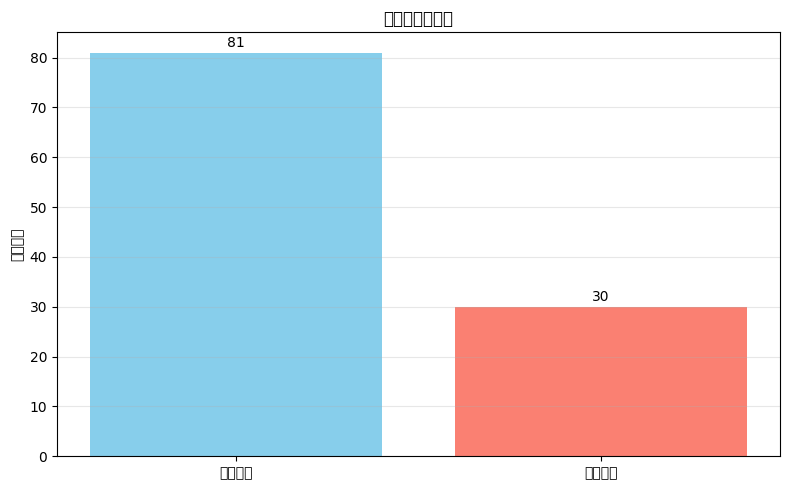


🎉 单元格3完成！


In [3]:
# ============================================================
# 单元格3：用最佳参数处理全部数据
# 版本：v3.1_202501
# ============================================================

print("📊 使用最佳参数处理全部数据")

# 检查依赖
if 'best_config_scientific_v21' not in globals():
    # 尝试从文件加载最佳配置
    try:
        with open('best_config_scientific_v21.json', 'r', encoding='utf-8') as f:
            best_config_v3 = json.load(f)
        print(f"✅ 从文件加载最佳配置: {best_config_v3['name']}")
    except:
        print("⚠️  找不到科学实验的最佳配置，使用默认配置")
        best_config_v3 = {'name': '2s_50%', 'segment_length': 2.0, 'overlap': 0.5}
        print(f"⚠️  使用默认配置: {best_config_v3['name']}")
else:
    best_config_v3 = best_config_scientific_v21

# 文件路径
audio_label_pairs_v3 = audio_label_pairs_v2  # 使用相同的文件列表

# ---------------------------------------------------------
# 处理所有数据
# ---------------------------------------------------------
# 确保使用正确的最佳配置
print(f"\n🔧 使用最佳配置: {best_config_v3['name']}")
print(f"  窗口大小: {best_config_v3['segment_length']}秒")
print(f"  重叠比例: {best_config_v3['overlap']}")

# 检查配置是否与科学实验选择一致
if 'metrics' in best_config_v3:
    print(f"  科学实验指标:")
    print(f"    - 准确率: {best_config_v3['metrics'].get('accuracy_mean', 0):.2%}")
    print(f"    - 严重召回率: {best_config_v3['metrics'].get('recall_severe_mean', 0):.2%}")
    print(f"    - 选择策略: {best_config_v3.get('selection_strategy', 'N/A')}")

# 处理全部数据
X_all_v3, y_all_v3 = process_multiple_v2(
    audio_label_pairs_v3,
    segment_length=best_config_v3['segment_length'],
    overlap=best_config_v3['overlap'],
    config_name=f"best_{best_config_v3['name']}"
)

if X_all_v3 is None:
    print("❌ 数据处理失败，请检查文件路径")
else:
    print(f"\n✅ 数据处理完成")
    print(f"  总样本数: {len(X_all_v3)}")
    print(f"  特征维度: {X_all_v3.shape[1]}")
    print(f"  正常鼾声: {np.sum(y_all_v3 == 0)}")
    print(f"  严重鼾声: {np.sum(y_all_v3 == 1)}")
    
    # 保存最终数据集
    data_final_v3 = save_data_v1(X_all_v3, y_all_v3, "final_dataset")
    
    # 显示类别分布
    plt.figure(figsize=(8, 5))
    labels = ['正常鼾声', '严重鼾声']
    counts = [np.sum(y_all_v3 == 0), np.sum(y_all_v3 == 1)]
    
    plt.bar(labels, counts, color=['skyblue', 'salmon'])
    plt.title('数据集类别分布')
    plt.ylabel('样本数量')
    
    # 在柱状图上显示数字
    for i, count in enumerate(counts):
        plt.text(i, count + 0.5, str(count), ha='center', va='bottom')
    
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n🎉 单元格3完成！")

🧠 训练最终模型（三分类：正常/严重/背景）
✅ 数据准备就绪: 264个样本
  类别分布: 0=81, 1=30, 2=153

🚀 开始训练三分类模型...
   训练集: 211个
   测试集: 53个
   测试集分布: 0=16, 1=6, 2=31

⏳ 训练中...
Epoch 1/60
 1/11 ━━━━━━━━━━━━━━━━━━━━ 9s 970ms/step - accuracy: 0.2500 - loss: 1.2056
Epoch 1: val_accuracy improved from None to 0.58140, saving model to snore_detector_3class_best.keras

Epoch 1: finished saving model to snore_detector_3class_best.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2917 - loss: 1.2526 - val_accuracy: 0.5814 - val_loss: 1.0612
Epoch 2/60
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4375 - loss: 1.0146
Epoch 2: val_accuracy improved from 0.58140 to 0.65116, saving model to snore_detector_3class_best.keras

Epoch 2: finished saving model to snore_detector_3class_best.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4286 - loss: 1.1496 - val_accuracy: 0.6512 - val_loss: 1.0008
Epoch 3/60
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3125 - loss: 1.1028
Epoch 3: val_accuracy did n

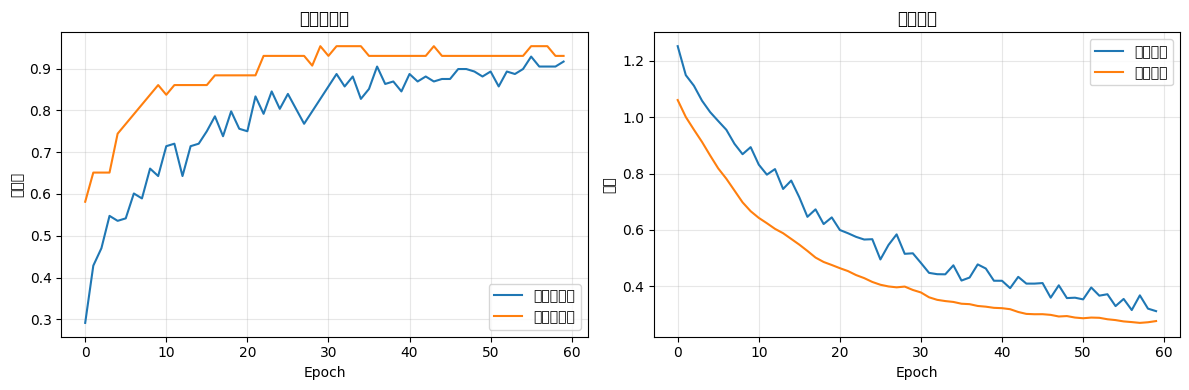


✅ 模型训练完成!
   💾 模型: snore_detector_3class_final.keras
   💾 Scaler: snore_detector_3class_scaler.pkl

🎉 单元格4完成！三分类模型已保存


In [4]:
# ============================================================
# 单元格4：训练最终模型（三分类版）
# 版本：v4.3_三分类_完整可直接替换
# ============================================================

print("🧠 训练最终模型（三分类：正常/严重/背景）")

import json
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import joblib

# 检查数据
if 'X_all_v3' not in globals() or 'y_all_v3' not in globals():
    print("❌ 请先运行单元格3")
    raise ValueError("数据未准备")

print(f"✅ 数据准备就绪: {len(X_all_v3)}个样本")
print(f"  类别分布: 0={np.sum(y_all_v3==0)}, 1={np.sum(y_all_v3==1)}, 2={np.sum(y_all_v3==2)}")

def train_final_model_3class_v43(X_all, y_all, model_name="snore_3class_v43"):
    """训练三分类最终模型"""
    print(f"\n🚀 开始训练三分类模型...")
    
    # 1. 标准化
    scaler_v4 = StandardScaler()
    X_scaled_v4 = scaler_v4.fit_transform(X_all)
    
    # 2. 划分数据集
    X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(
        X_scaled_v4, y_all, 
        test_size=0.2, 
        random_state=42,
        stratify=y_all
    )
    
    print(f"   训练集: {len(y_train_v4)}个")
    print(f"   测试集: {len(y_test_v4)}个")
    print(f"   测试集分布: 0={np.sum(y_test_v4==0)}, 1={np.sum(y_test_v4==1)}, 2={np.sum(y_test_v4==2)}")
    
    # 3. 构建三分类模型（关键修改：输出3类）
    model_v4 = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_v4.shape[1],),
                             kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(32, activation='relu',
                             kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax')  # 三分类输出
    ])
    
    # 4. 编译
    model_v4.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # 5. 回调函数
    callbacks_v4 = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'{model_name}_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]
    
    # 6. 训练
    print(f"\n⏳ 训练中...")
    history_v4 = model_v4.fit(
        X_train_v4, y_train_v4,
        epochs=60,
        batch_size=16,
        validation_split=0.2,
        callbacks=callbacks_v4,
        verbose=1
    )
    
    # 7. 加载最佳模型
    try:
        model_v4 = tf.keras.models.load_model(f'{model_name}_best.keras')
        print("✅ 已加载最佳模型权重")
    except:
        print("⚠️  使用当前模型")
    
    # 8. 评估
    print("\n📊 详细评估:")
    y_pred_proba = model_v4.predict(X_test_v4, verbose=0)
    y_pred_classes = np.argmax(y_pred_proba, axis=1)
    
    # 分类报告（三分类）
    target_names = ['正常吸气(0)', '严重吸气(1)', '背景/呼气(2)']
    print(classification_report(y_test_v4, y_pred_classes, target_names=target_names, digits=4))
    
    # 混淆矩阵（3x3）
    cm = confusion_matrix(y_test_v4, y_pred_classes)
    print(f"\n混淆矩阵 (行=真实, 列=预测):")
    print(f"         预0    预1    预2")
    for i, row in enumerate(cm):
        print(f"真{i}: {row}")
    
    # 计算吸气鼾声的漏检率（真1被预测为0或2的比例）
    severe_samples = y_test_v4 == 1
    severe_total = np.sum(severe_samples)
    if severe_total > 0:
        severe_pred = y_pred_classes[severe_samples]
        missed = np.sum((severe_pred == 0) | (severe_pred == 2))
        miss_rate = missed / severe_total
        print(f"\n⚠️  严重吸气鼾声漏检率: {miss_rate:.2%} ({missed}/{severe_total})")
        
        if miss_rate > 0.2:
            print("   🚨 警告：漏检率>20%，建议增加严重样本")
    
    # 9. 可视化训练曲线
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history_v4.history['accuracy'], label='训练准确率')
    plt.plot(history_v4.history['val_accuracy'], label='验证准确率')
    plt.title('模型准确率')
    plt.xlabel('Epoch')
    plt.ylabel('准确率')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(history_v4.history['loss'], label='训练损失')
    plt.plot(history_v4.history['val_loss'], label='验证损失')
    plt.title('模型损失')
    plt.xlabel('Epoch')
    plt.ylabel('损失')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 10. 保存
    model_v4.save(f'{model_name}_final.keras')
    joblib.dump(scaler_v4, f'{model_name}_scaler.pkl')
    
    print(f"\n✅ 模型训练完成!")
    print(f"   💾 模型: {model_name}_final.keras")
    print(f"   💾 Scaler: {model_name}_scaler.pkl")
    
    # 返回兼容的格式
    return {
        'model': model_v4,
        'scaler': scaler_v4,
        'history': history_v4,
        'config': best_config_scientific_v21 if 'best_config_scientific_v21' in globals() else {}
    }

# 训练模型
if 'X_all_v3' in globals():
    model_info_v4 = train_final_model_3class_v43(X_all_v3, y_all_v3, "snore_detector_3class")
    print("\n🎉 单元格4完成！三分类模型已保存")
else:
    print("❌ 错误：找不到数据")

🎯 预测推理：支持m4a/mp3/wav等多种音频格式
✅ 三分类模型加载成功

🔬 分析: snoring-8.m4a
🎧 处理音频: snoring-8.m4a
   音频长度: 1543.7s, 采样率: 48000Hz
   片段预测: 正常=791, 严重=83, 背景=2212
   步骤2: 分层合并+异类重叠合并...
   分层合并: max_gap=0.5s, short_gap=0.3s
   [步骤1] 吸气鼾声合并: 正常=197个, 严重=51个
   [步骤2] 呼气/间隙合并: 120个事件
   [步骤3] 跨间隙再合并后: 正常=197个, 严重=49个
   [步骤4] 异类重叠合并后: 201个事件

👤 用户视角报告（分层合并+异类重叠合并）
事件ID     开始         结束         持续(s)      类型           置信度      说明             
--------------------------------------------------------------------------------
1        14.0       16.5       2.5        正常吸气         0.77                    
2        18.0       20.0       2.0        正常吸气         0.78                    
3        26.0       27.0       1.0        正常吸气         0.43                    
4        30.0       31.0       1.0        正常吸气         0.39                    
5        32.0       33.0       1.0        正常吸气         0.43                    
6        35.5       37.0       1.5        正常吸气         0.53                    
7        38.

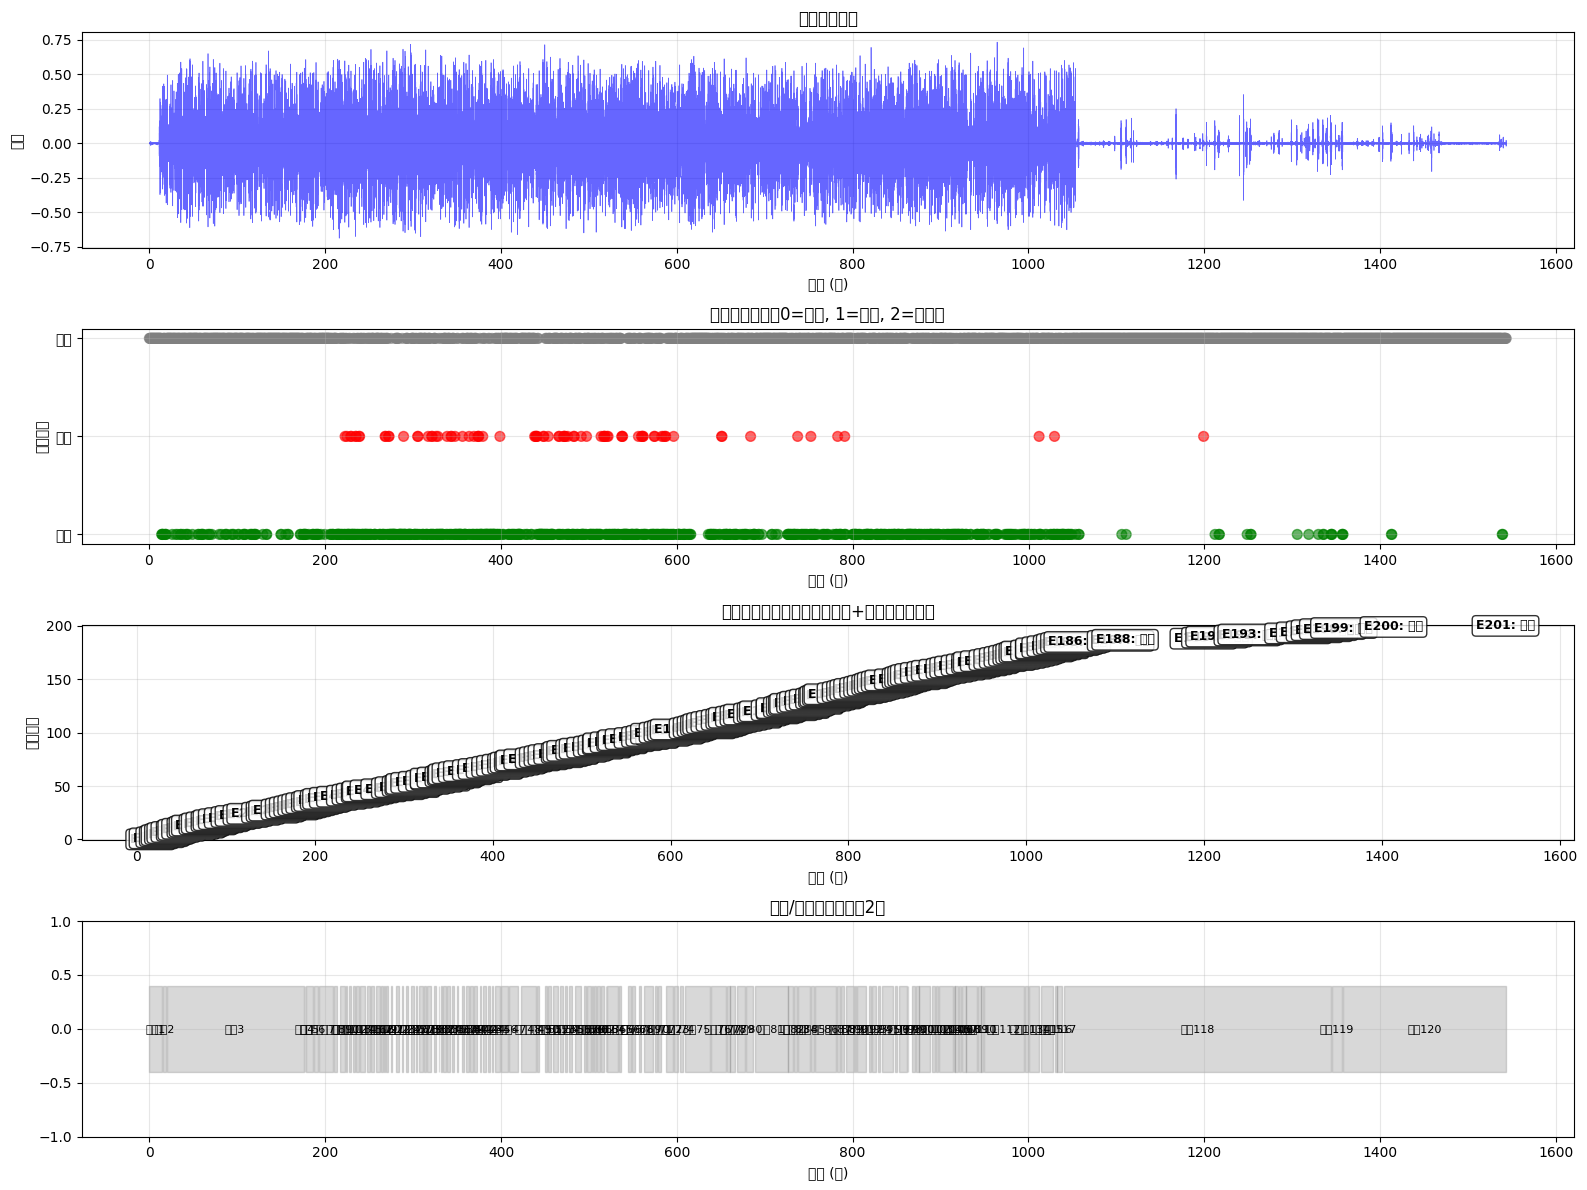


🎉 分析完成！检测到 201 个吸气鼾声事件

📋 格式支持说明
✅ 原生支持: wav, mp3（如果ffmpeg已安装）
✅ 转换支持: m4a, aac, ogg, flac, wma（需安装pydub和ffmpeg）
📥 安装命令: pip install pydub
🌐 ffmpeg下载: https://ffmpeg.org/download.html


In [5]:
# 单元格5：预测推理 - 支持m4a/mp3等格式（完整版）
# 版本：v5.6_支持多格式音频_m4a兼容
# ============================================================

print("🎯 预测推理：支持m4a/mp3/wav等多种音频格式")

import os
import json
import numpy as np
import librosa
import matplotlib.pyplot as plt
from datetime import datetime
import tensorflow as tf
import io

# 尝试导入pydub（用于m4a转换）
try:
    from pydub import AudioSegment
    PYDUB_AVAILABLE = True
except ImportError:
    PYDUB_AVAILABLE = False
    print("⚠️  提示：安装pydub以支持m4a格式: pip install pydub")
    print("   同时需要安装ffmpeg: https://ffmpeg.org/download.html")

# 检查依赖
if 'model_info_v4' not in globals():
    print("❌ 请先运行单元格4训练模型")
    raise ValueError("模型未加载")
else:
    model_v5 = model_info_v4['model']
    scaler_v5 = model_info_v4['scaler']
    print(f"✅ 三分类模型加载成功")

# ---------------------------------------------------------
# 新增：通用音频加载函数（支持m4a/mp3等）
# ---------------------------------------------------------
def load_audio_universal(audio_path, sr=None):
    """
    通用音频加载函数，支持wav/mp3/m4a/aac等格式
    优先使用librosa（如果ffmpeg已安装），失败则使用pydub转换
    """
    ext = os.path.splitext(audio_path)[1].lower()
    
    # 首先尝试librosa直接加载（wav/mp3通常直接支持，m4a需要ffmpeg）
    try:
        y, sr_loaded = librosa.load(audio_path, sr=sr)
        return y, sr_loaded
    except Exception as e:
        # 如果是m4a/aac/ogg等格式，尝试用pydub转换
        if ext in ['.m4a', '.aac', '.ogg', '.wma', '.flac'] and PYDUB_AVAILABLE:
            print(f"   📝 检测到 {ext} 格式，使用pydub转换...")
            
            # 根据扩展名确定格式
            format_map = {
                '.m4a': 'mp4',  # pydub中m4a用mp4格式读取
                '.aac': 'aac',
                '.ogg': 'ogg',
                '.wma': 'wma',
                '.flac': 'flac'
            }
            audio_format = format_map.get(ext, ext[1:])
            
            # 加载并转换为wav内存数据
            audio = AudioSegment.from_file(audio_path, format=audio_format)
            
            # 转换为wav格式（内存中）
            buf = io.BytesIO()
            audio.export(buf, format="wav")
            buf.seek(0)
            
            # 使用librosa读取内存中的wav
            y, sr_loaded = librosa.load(buf, sr=sr)
            print(f"   ✅ {ext} 转换成功")
            return y, sr_loaded
        else:
            if ext in ['.m4a', '.aac'] and not PYDUB_AVAILABLE:
                raise ImportError(
                    f"❌ 无法加载 {ext} 文件。\n"
                    f"   请安装: pip install pydub\n"
                    f"   并安装ffmpeg: https://ffmpeg.org/download.html\n"
                    f"   或将音频转换为wav格式后再检测。"
                )
            else:
                raise e

# ---------------------------------------------------------
# 辅助函数：JSON序列化
# ---------------------------------------------------------
def convert_to_serializable(obj):
    """递归转换NumPy类型为Python原生类型"""
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(i) for i in obj]
    else:
        return obj

# ---------------------------------------------------------
# 核心函数1：三分类切片预测（支持多格式）
# ---------------------------------------------------------
def segment_and_predict_3class_v5(audio_path, model, scaler, 
                                 segment_length=1.0, overlap=0.5):
    """
    三分类切片预测：支持wav/mp3/m4a等多种格式
    """
    print(f"🎧 处理音频: {os.path.basename(audio_path)}")
    
    # 使用通用加载函数（支持m4a）
    try:
        y_audio, sr = load_audio_universal(audio_path, sr=None)
    except Exception as e:
        print(f"❌ 音频加载失败: {e}")
        raise
    
    total_duration = len(y_audio) / sr
    print(f"   音频长度: {total_duration:.1f}s, 采样率: {sr}Hz")
    
    # 计算切片参数
    samples_per_seg = int(segment_length * sr)
    step_samples = int(samples_per_seg * (1 - overlap))
    segments = []
    
    for start_sample in range(0, len(y_audio) - samples_per_seg + 1, step_samples):
        end_sample = start_sample + samples_per_seg
        segment_audio = y_audio[start_sample:end_sample]
        start_time = start_sample / sr
        end_time = end_sample / sr
        
        # 特征提取
        features = extract_enhanced_features_v1(segment_audio, sr)
        features_scaled = scaler.transform(features.reshape(1, -1))
        prediction = model.predict(features_scaled, verbose=0)
        
        pred_type = int(np.argmax(prediction[0]))
        confidence = float(prediction[0][pred_type])
        
        segments.append({
            'start': round(start_time, 2),
            'end': round(end_time, 2),
            'type': pred_type,
            'confidence': round(confidence, 3),
            'center': round((start_time + end_time) / 2, 2),
            'probs': prediction[0].tolist()
        })
    
    # 统计
    count_0 = sum(1 for s in segments if s['type'] == 0)
    count_1 = sum(1 for s in segments if s['type'] == 1)
    count_2 = sum(1 for s in segments if s['type'] == 2)
    print(f"   片段预测: 正常={count_0}, 严重={count_1}, 背景={count_2}")
    
    return segments, total_duration, y_audio, sr

# ---------------------------------------------------------
# 核心函数2：分层合并+异类重叠合并（保持不变）
# ---------------------------------------------------------
def merge_hierarchical_with_overlap_v5(segments, max_gap=0.5, short_gap=0.3):
    """
    分层合并+异类重叠合并策略
    """
    if not segments:
        return []
    
    print(f"   分层合并: max_gap={max_gap}s, short_gap={short_gap}s")
    
    def merge_same_type_events(event_list, gap_threshold):
        """合并时间相邻的同类事件"""
        if not event_list:
            return []
        
        sorted_events = sorted(event_list, key=lambda x: x['start'])
        merged = []
        current = sorted_events[0].copy()
        current['segment_count'] = 1
        
        for next_evt in sorted_events[1:]:
            gap = next_evt['start'] - current['end']
            
            if next_evt['type'] == current['type'] and gap <= gap_threshold:
                current['end'] = next_evt['end']
                current['duration'] = current['end'] - current['start']
                current['confidence'] = max(current['confidence'], next_evt['confidence'])
                current['segment_count'] += 1
            else:
                merged.append(current)
                current = next_evt.copy()
                current['segment_count'] = 1
        
        merged.append(current)
        return merged
    
    # 步骤1: 分别合并吸气鼾声（0和1各自合并）
    segs_0 = [s for s in segments if s['type'] == 0]
    segs_1 = [s for s in segments if s['type'] == 1]
    
    merged_0 = merge_same_type_events(segs_0, max_gap)
    merged_1 = merge_same_type_events(segs_1, max_gap)
    
    print(f"   [步骤1] 吸气鼾声合并: 正常={len(merged_0)}个, 严重={len(merged_1)}个")
    
    # 步骤2: 呼气合并（合并背景类2）
    segs_2 = [s for s in segments if s['type'] == 2]
    merged_2 = merge_same_type_events(segs_2, max_gap)
    print(f"   [步骤2] 呼气/间隙合并: {len(merged_2)}个事件")
    
    # 步骤3: 跨短间隙再合并（同类跨背景合并）
    def merge_across_short_gaps(main_events, gap_events, gap_threshold):
        """跨短间隙合并"""
        if not gap_events or len(main_events) < 2:
            return main_events
        
        all_events = sorted(main_events + gap_events, key=lambda x: x['start'])
        result = []
        i = 0
        
        while i < len(all_events):
            current = all_events[i]
            
            if (current.get('type') in [0, 1] and 
                i + 2 < len(all_events)):
                
                middle = all_events[i + 1]
                after = all_events[i + 2]
                
                if (middle.get('type') == 2 and 
                    middle.get('duration', 0) < gap_threshold and
                    after.get('type') == current.get('type')):
                    
                    merged_event = {
                        'start': current['start'],
                        'end': after['end'],
                        'type': current['type'],
                        'duration': after['end'] - current['start'],
                        'confidence': max(current['confidence'], after['confidence']),
                        'segment_count': (current.get('segment_count', 1) + 
                                        middle.get('segment_count', 1) + 
                                        after.get('segment_count', 1)),
                        'crossed_gap': True,
                        'gap_duration': middle.get('duration', 0)
                    }
                    result.append(merged_event)
                    i += 3
                    continue
            
            if current.get('type') in [0, 1]:
                result.append(current)
            i += 1
        
        return result
    
    final_0 = merge_across_short_gaps(merged_0, merged_2, short_gap)
    final_1 = merge_across_short_gaps(merged_1, merged_2, short_gap)
    
    print(f"   [步骤3] 跨间隙再合并后: 正常={len(final_0)}个, 严重={len(final_1)}个")
    
    # 步骤4: 异类重叠合并（0类和1类时间重叠时合并为严重）
    def merge_overlapping_types(events_0, events_1):
        """合并时间重叠的0类和1类事件（严重优先）"""
        if not events_0 or not events_1:
            return events_0 + events_1
        
        result = []
        used_1 = set()
        
        for evt_0 in events_0:
            overlapping_severe = []
            
            for i, evt_1 in enumerate(events_1):
                if i in used_1:
                    continue
                # 检查时间重叠
                if not (evt_0['end'] <= evt_1['start'] or evt_0['start'] >= evt_1['end']):
                    overlapping_severe.append((i, evt_1))
            
            if overlapping_severe:
                # 有重叠的严重事件，合并（严重优先）
                all_starts = [evt_0['start']] + [e[1]['start'] for e in overlapping_severe]
                all_ends = [evt_0['end']] + [e[1]['end'] for e in overlapping_severe]
                all_confs = [evt_0['confidence']] + [e[1]['confidence'] for e in overlapping_severe]
                all_counts = [evt_0.get('segment_count', 1)] + [e[1].get('segment_count', 1) for e in overlapping_severe]
                
                merged_event = {
                    'start': min(all_starts),
                    'end': max(all_ends),
                    'duration': max(all_ends) - min(all_starts),
                    'type': 1,  # 严重优先
                    'confidence': min(all_confs),
                    'segment_count': sum(all_counts),
                    'merged_types': '0+1',
                    'source_normal': evt_0,
                    'source_severe': [e[1] for e in overlapping_severe]
                }
                result.append(merged_event)
                
                for i, _ in overlapping_severe:
                    used_1.add(i)
            else:
                result.append(evt_0)
        
        for i, evt_1 in enumerate(events_1):
            if i not in used_1:
                result.append(evt_1)
        
        return result
    
    final_mixed = merge_overlapping_types(final_0, final_1)
    print(f"   [步骤4] 异类重叠合并后: {len(final_mixed)}个事件")
    
    # 合并所有事件（0/1合并后的 + 背景类2），按时间排序
    all_final = sorted(final_mixed + merged_2, key=lambda x: x['start'])
    
    return all_final

# ---------------------------------------------------------
# 核心函数3：完整预测流程（保持不变）
# ---------------------------------------------------------
def predict_audio_3class_v5(audio_path, model, scaler,
                           segment_length=1.0,
                           overlap=0.5,
                           merge_gap=0.5,
                           short_gap=0.3):
    """
    完整的预测流程（支持m4a等多种格式）
    """
    print(f"\n{'='*60}")
    print(f"🔬 分析: {os.path.basename(audio_path)}")
    print(f"{'='*60}")
    
    # 步骤1: 切片预测（支持m4a）
    segments, total_duration, y_audio, sr = segment_and_predict_3class_v5(
        audio_path, model, scaler,
        segment_length=segment_length,
        overlap=overlap
    )
    
    if not segments:
        print("⚠️ 未生成任何片段")
        return [], total_duration
    
    # 步骤2: 分层合并+异类重叠合并
    print(f"   步骤2: 分层合并+异类重叠合并...")
    merged_events = merge_hierarchical_with_overlap_v5(
        segments, 
        max_gap=merge_gap,
        short_gap=short_gap
    )
    
    # 步骤3: 生成报告
    print_user_report_v5(merged_events, total_duration)
    
    # 步骤4: 可视化
    visualize_3class_results_v5(y_audio, sr, merged_events, segments)
    
    return merged_events, total_duration

# ---------------------------------------------------------
# 用户报告（保持不变）
# ---------------------------------------------------------
def print_user_report_v5(events, total_duration):
    """生成用户视角报告"""
    print("\n" + "="*80)
    print("👤 用户视角报告（分层合并+异类重叠合并）")
    print("="*80)
    
    snore_events = [e for e in events if e.get('type') in [0, 1]]
    
    if not snore_events:
        print("📊 未检测到吸气鼾声事件")
        return
    
    type_names = {0: "正常吸气", 1: "严重吸气"}
    
    print(f"{'事件ID':<8} {'开始':<10} {'结束':<10} {'持续(s)':<10} {'类型':<12} {'置信度':<8} {'说明':<15}")
    print("-"*80)
    
    total_snore_time = 0
    type_counts = {0: 0, 1: 0}
    
    for i, event in enumerate(snore_events, 1):
        duration = event.get('duration', event['end'] - event['start'])
        type_str = type_names[event['type']]
        
        note = ""
        if event.get('crossed_gap'):
            note = f"(跨{event['gap_duration']:.1f}s间隙)"
        elif event.get('merged_types') == '0+1':
            note = "(0+1合并)"
        
        print(f"{i:<8} {event['start']:<10.1f} {event['end']:<10.1f} "
              f"{duration:<10.1f} {type_str:<12} {event['confidence']:<8.2f} {note:<15}")
        
        type_counts[event['type']] += 1
        total_snore_time += duration
    
    print("\n" + "="*80)
    print("📈 统计摘要")
    print("-"*80)
    print(f"🔹 音频总时长: {total_duration:.1f}秒")
    print(f"🔹 吸气鼾声事件: {len(snore_events)}个")
    print(f"   - 正常吸气: {type_counts[0]}个")
    print(f"   - 严重吸气: {type_counts[1]}个")
    print(f"🔹 吸气鼾声总时长: {total_snore_time:.1f}秒")
    
    if total_duration > 0:
        ratio = (total_snore_time / total_duration) * 100
        print(f"🔹 吸气鼾声占比: {ratio:.1f}%")
    
    bg_events = [e for e in events if e.get('type') == 2]
    if bg_events:
        bg_time = sum(e.get('duration', e['end']-e['start']) for e in bg_events)
        print(f"🔹 呼气/间隙时间: {bg_time:.1f}秒 ({(bg_time/total_duration)*100:.1f}%)")
    
    print("\n" + "="*80)
    print("⚠️  医疗风险评估")
    print("-"*80)
    
    if type_counts[1] > 0:
        severe_time = sum(e.get('duration', e['end']-e['start']) 
                         for e in snore_events if e['type'] == 1)
        severe_ratio = (severe_time / total_duration) * 100
        
        print(f"🔴 严重吸气鼾声: {type_counts[1]}个事件, {severe_time:.1f}秒 ({severe_ratio:.1f}%)")
        
        if severe_ratio > 10:
            print("🚨 高风险: 严重鼾声占比>10%，建议就医")
        elif severe_ratio > 5:
            print("⚠️  中风险: 建议持续监测")
        else:
            print("✅ 低风险")
    else:
        print("✅ 未检测到严重吸气鼾声")
    
    report_data = {
        'analysis_time': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'total_duration': total_duration,
        'events': convert_to_serializable(snore_events),
        'summary': {
            'total_events': len(snore_events),
            'normal_count': type_counts[0],
            'severe_count': type_counts[1],
            'total_snore_time': total_snore_time
        }
    }
    
    with open('prediction_report_v55.json', 'w', encoding='utf-8') as f:
        json.dump(report_data, f, ensure_ascii=False, indent=2)
    
    print(f"\n💾 报告已保存: prediction_report_v55.json")

# ---------------------------------------------------------
# 可视化（保持不变）
# ---------------------------------------------------------
def visualize_3class_results_v5(y_audio, sr, events, raw_segments):
    """三分类结果可视化"""
    fig, axes = plt.subplots(4, 1, figsize=(16, 12))
    time_axis = np.linspace(0, len(y_audio)/sr, len(y_audio))
    
    axes[0].plot(time_axis, y_audio, color='blue', alpha=0.6, linewidth=0.5)
    axes[0].set_title('原始音频波形')
    axes[0].set_xlabel('时间 (秒)')
    axes[0].set_ylabel('振幅')
    axes[0].grid(True, alpha=0.3)
    
    seg_times = [s['center'] for s in raw_segments]
    seg_types = [s['type'] for s in raw_segments]
    
    colors_map = {0: 'green', 1: 'red', 2: 'gray'}
    seg_colors = [colors_map[t] for t in seg_types]
    
    axes[1].scatter(seg_times, seg_types, c=seg_colors, alpha=0.6, s=50)
    axes[1].set_title('原始片段预测（0=正常, 1=严重, 2=背景）')
    axes[1].set_xlabel('时间 (秒)')
    axes[1].set_ylabel('预测类型')
    axes[1].set_yticks([0, 1, 2])
    axes[1].set_yticklabels(['正常', '严重', '背景'])
    axes[1].grid(True, alpha=0.3)
    
    snore_events = [e for e in events if e.get('type') in [0, 1]]
    axes[2].set_title('合并后的吸气鼾声事件（分层+异类重叠合并）')
    
    colors_evt = {0: 'green', 1: 'red'}
    labels_evt = {0: '正常', 1: '严重'}
    
    y_pos = 0
    
    for idx, event in enumerate(snore_events):
        evt_type = event['type']
        color = colors_evt[evt_type]
        
        axes[2].fill_between(
            [event['start'], event['end']],
            y_pos - 0.4, y_pos + 0.4,
            alpha=0.3,
            color=color
        )
        
        center = (event['start'] + event['end']) / 2
        label = f"E{idx+1}: {labels_evt[evt_type]}"
        if event.get('merged_types') == '0+1':
            label += "*"
        axes[2].text(center, y_pos, label, ha='center', va='center', 
                    fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
        
        y_pos += 1
    
    axes[2].set_xlabel('时间 (秒)')
    axes[2].set_ylabel('事件序号')
    axes[2].set_ylim(-1, max(len(snore_events), 1))
    axes[2].grid(True, alpha=0.3)
    
    bg_events = [e for e in events if e.get('type') == 2]
    axes[3].set_title('呼气/间隙事件（类型2）')
    
    for idx, event in enumerate(bg_events):
        axes[3].fill_between(
            [event['start'], event['end']],
            -0.4, 0.4,
            alpha=0.3,
            color='gray'
        )
        center = (event['start'] + event['end']) / 2
        axes[3].text(center, 0, f"间隙{idx+1}", ha='center', va='center', fontsize=8)
    
    axes[3].set_xlabel('时间 (秒)')
    axes[3].set_ylim(-1, 1)
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 运行预测（支持m4a）
# ---------------------------------------------------------
# 测试m4a音频（修改为你的m4a文件路径）
test_audio_v5 = './my_mp3_snores/snoring-8.m4a'  # 改为你的m4a文件路径

# 如果m4a不存在，尝试mp3或wav
if not os.path.exists(test_audio_v5):
    test_audio_v5 = './my_mp3_snores/snoring-6.mp3'
if not os.path.exists(test_audio_v5):
    test_audio_v5 = './my_mp3_snores/snoring-6.wav'

if os.path.exists(test_audio_v5):
    try:
        events_result, duration = predict_audio_3class_v5(
            test_audio_v5,
            model_v5,
            scaler_v5,
            segment_length=1.0,
            overlap=0.5,
            merge_gap=0.5,
            short_gap=0.3
        )
        
        print(f"\n🎉 分析完成！检测到 {len([e for e in events_result if e.get('type') in [0,1]])} 个吸气鼾声事件")
        
    except Exception as e:
        print(f"\n❌ 预测过程出错: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"⚠️  测试音频不存在: {test_audio_v5}")
    print("   请修改 test_audio_v5 变量为你的音频路径（支持m4a/mp3/wav）")

print("\n" + "="*80)
print("📋 格式支持说明")
print("="*80)
print("✅ 原生支持: wav, mp3（如果ffmpeg已安装）")
print("✅ 转换支持: m4a, aac, ogg, flac, wma（需安装pydub和ffmpeg）")
print("📥 安装命令: pip install pydub")
print("🌐 ffmpeg下载: https://ffmpeg.org/download.html")